# 🫀 Heart Disease Prediction

Machine Learning semester project — predicting heart disease from patient health records.

**Models compared:** K-Nearest Neighbors, Logistic Regression, Support Vector Classifier, Decision Tree, Random Forest, Naive Bayes, XGBoost  
**Best model:** KNN with **87%** accuracy

*Author: Ayesha Shoukat — CS @ UET Narowal*

In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Load dataset — works locally AND in Google Colab
import os
csv_path = 'dataset_hdp.csv'
if not os.path.exists(csv_path):
    # Fallback: load from Google Drive when running in Colab
    from google.colab import drive
    drive.mount('/content/drive')
    csv_path = '/content/drive/MyDrive/ML Project Sem 5/dataset hdp.csv'
dataset = pd.read_csv(csv_path)
print('Dataset loaded:', dataset.shape)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
dataset.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


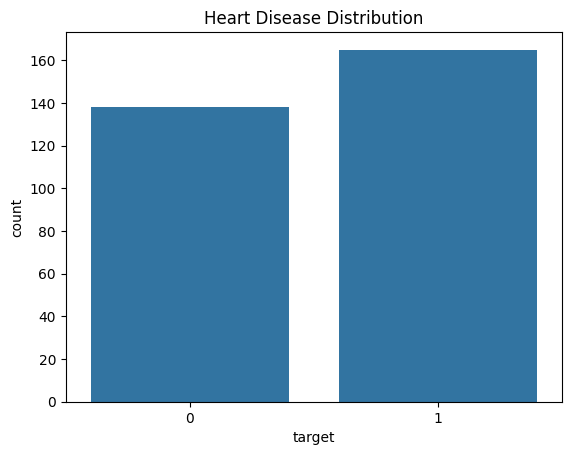

In [ ]:
sns.countplot(x='target', data=dataset)
plt.title("Heart Disease Distribution")
plt.show()


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

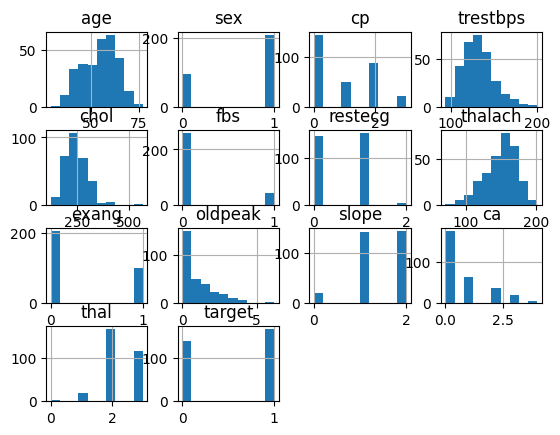

In [ ]:
dataset.hist()

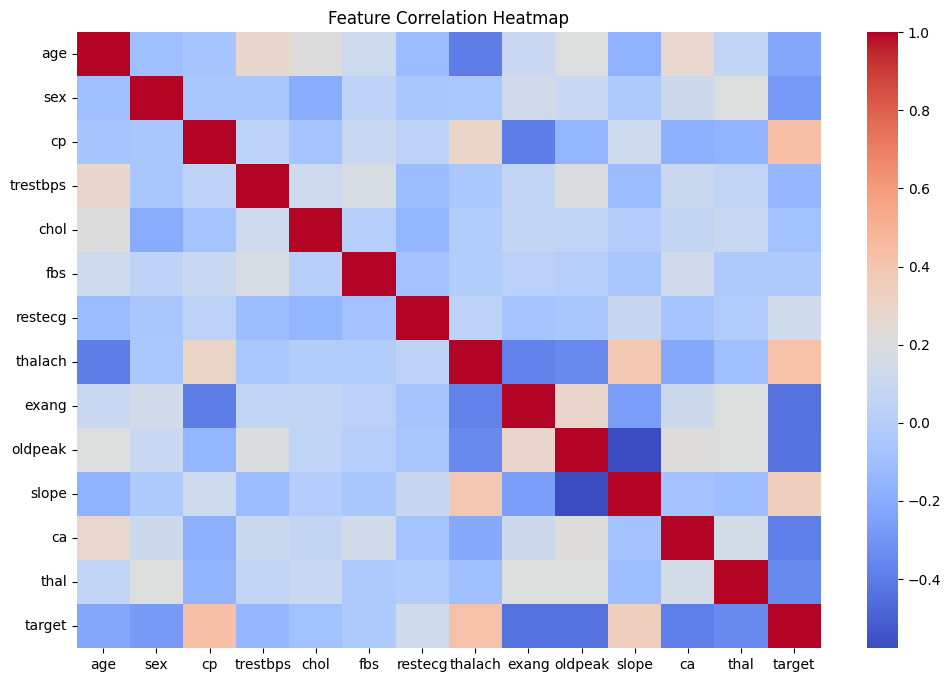

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
dataset = pd.get_dummies(dataset, columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

In [ ]:
standardScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standardScaler.fit_transform(dataset[columns_to_scale])

In [ ]:
y = dataset['target']
X = dataset.drop(['target'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

In [ ]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(knn_classifier.score(X_test, y_test))

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

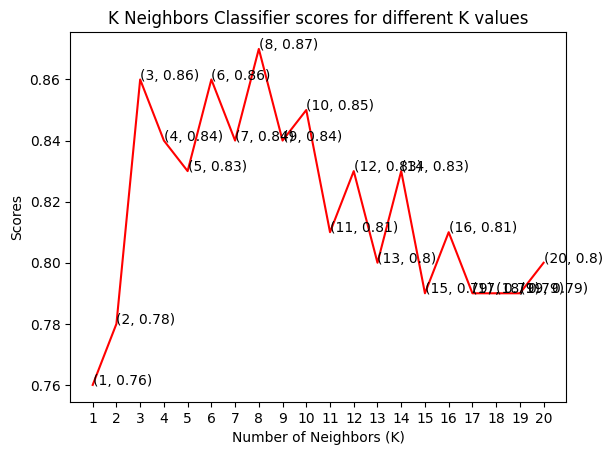

In [ ]:
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

In [ ]:
print("The score for K Neighbors Classifier is {}% with {} nieghbors.".format(knn_scores[7]*100, 8))

The score for K Neighbors Classifier is 87.0% with 8 nieghbors.


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

log_reg_score = log_reg.score(X_test, y_test)
print("Logistic Regression Accuracy: {:.2f}%".format(log_reg_score * 100))


Logistic Regression Accuracy: 84.00%


<Figure size 600x600 with 0 Axes>

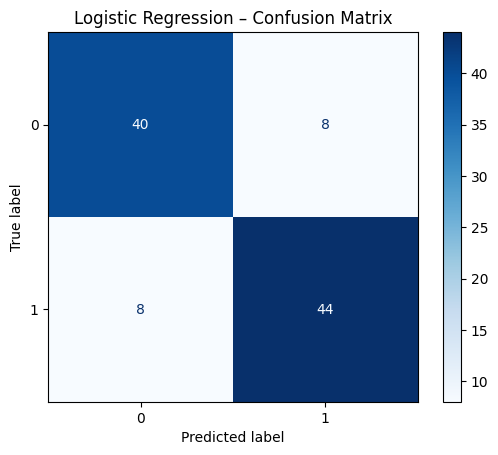

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Logistic Regression – Confusion Matrix")
plt.show()


In [ ]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(svc_classifier.score(X_test, y_test))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svc_predictions = {}

for kernel in kernels:
    svc = SVC(kernel=kernel)
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    svc_predictions[kernel] = y_pred


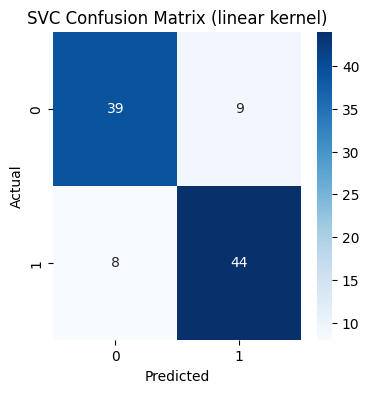

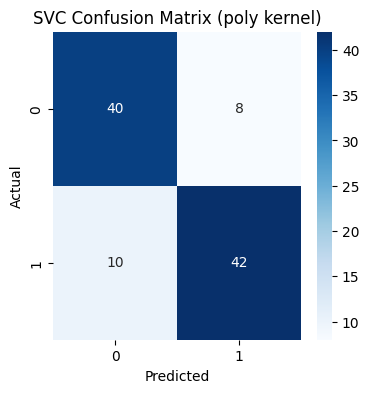

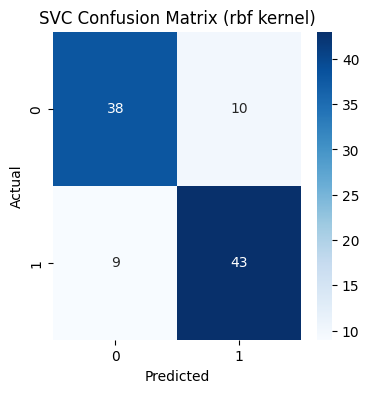

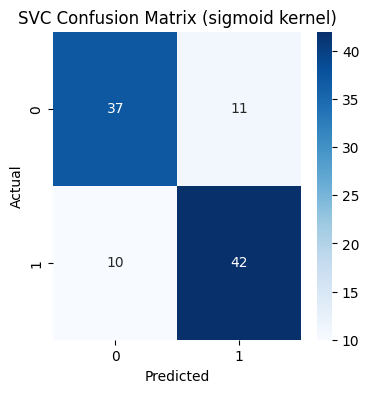

In [ ]:
for kernel, y_pred in svc_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"SVC Confusion Matrix ({kernel} kernel)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


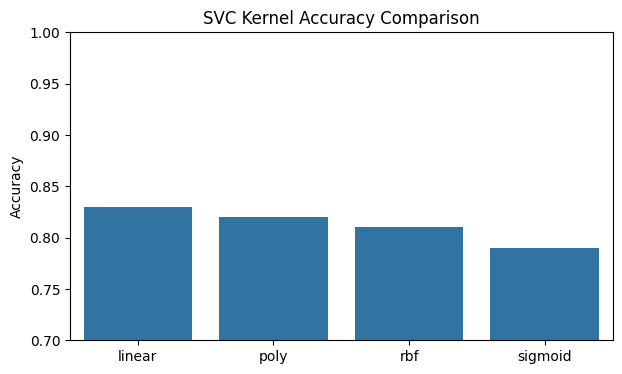

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x=kernels, y=svc_scores)
plt.ylabel("Accuracy")
plt.title("SVC Kernel Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.show()


In [ ]:
print("The score for Support Vector Classifier is {}% with {} kernel.".format(svc_scores[0]*100, 'linear'))

The score for Support Vector Classifier is 83.0% with linear kernel.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

dt_scores = []
features_range = range(1, X.shape[1] + 1)

for i in features_range:
    dt = DecisionTreeClassifier(
        max_features=i,
        random_state=0
    )
    dt.fit(X_train, y_train)
    score = dt.score(X_test, y_test)
    dt_scores.append(score)


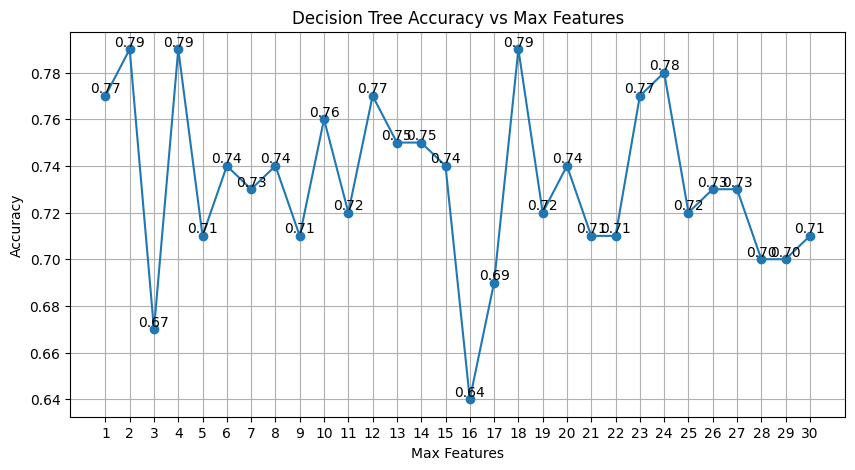

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(features_range, dt_scores, marker='o')

for i, score in zip(features_range, dt_scores):
    plt.text(i, score, f"{score:.2f}", ha='center', va='bottom')

plt.xticks(features_range)
plt.xlabel("Max Features")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Features")
plt.grid(True)
plt.show()


In [ ]:
best_score = max(dt_scores)
best_feature = features_range[dt_scores.index(best_score)]

print("Best Accuracy:", best_score)
print("Best max_features:", best_feature)


Best Accuracy: 0.79
Best max_features: 2


In [ ]:
dt_best = DecisionTreeClassifier(
    max_features=best_feature,
    random_state=0
)

dt_best.fit(X_train, y_train)


DecisionTreeClassifier(max_features=2, random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf_scores = []
trees_range = range(10, 210, 10)   # 10, 20, ..., 200

for n in trees_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=0
    )
    rf.fit(X_train, y_train)
    score = rf.score(X_test, y_test)
    rf_scores.append(score)


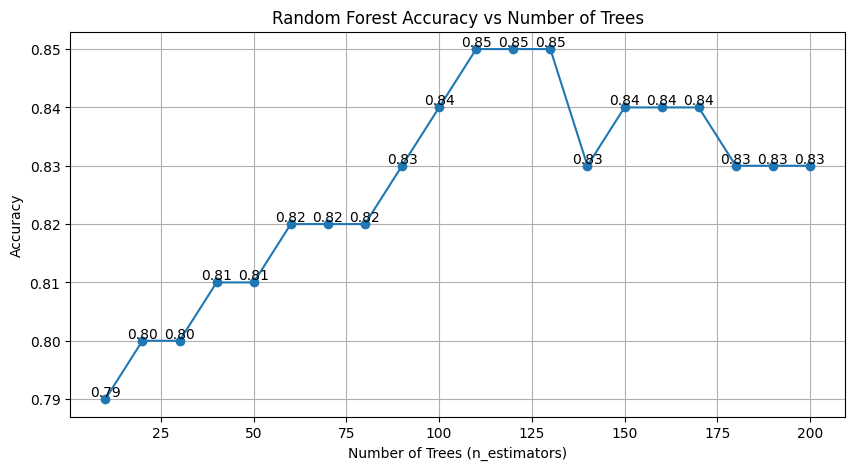

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(trees_range, rf_scores, marker='o')

for n, score in zip(trees_range, rf_scores):
    plt.text(n, score, f"{score:.2f}", ha='center', va='bottom')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()


In [ ]:
best_rf_score = max(rf_scores)
best_trees = trees_range[rf_scores.index(best_rf_score)]

print("Best Accuracy:", best_rf_score)
print("Best n_estimators:", best_trees)


Best Accuracy: 0.85
Best n_estimators: 110


In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=best_trees,
    random_state=0
)

rf_best.fit(X_train, y_train)


RandomForestClassifier(n_estimators=110, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

In [ ]:
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)


Naive Bayes Accuracy: 0.8


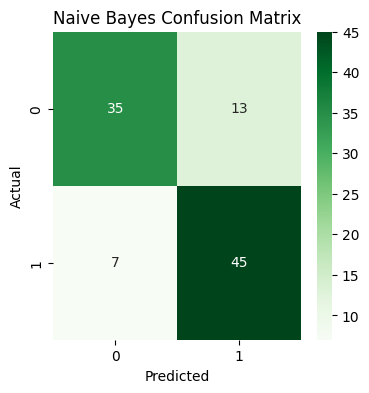

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(4,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.83      0.73      0.78        48
           1       0.78      0.87      0.82        52

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)


XGBoost Accuracy: 0.81


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)


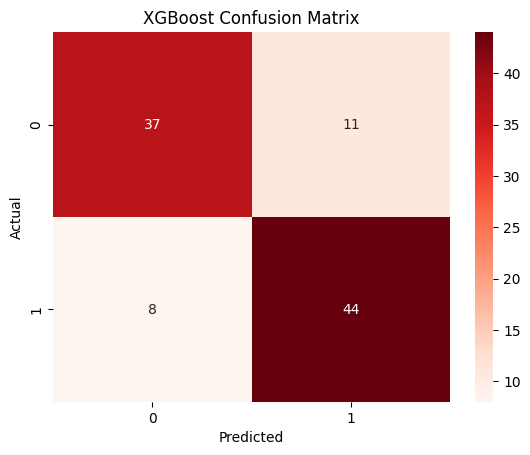

In [ ]:
plt.figure
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


ACCURACY COMPARISON OF ALL MODELS

                    Model  Accuracy
0     Logistic Regression      0.84
1           Decision Tree      0.71
2           Random Forest      0.83
3  Support Vector Machine      0.81


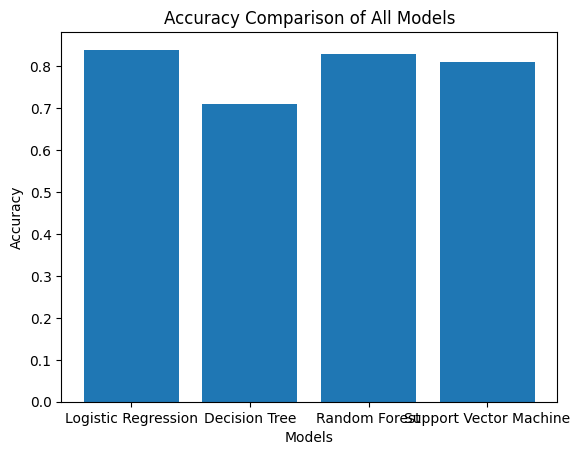


PREDICTION RESULTS (FIRST 10 TEST RECORDS)

   Actual Value  Logistic Regression Prediction  Decision Tree Prediction  \
0             0                               0                         1   
1             1                               0                         1   
2             0                               0                         1   
3             0                               0                         0   
4             1                               0                         0   
5             0                               0                         0   
6             0                               0                         1   
7             0                               0                         0   
8             0                               0                         0   
9             0                               0                         0   

   Random Forest Prediction  Support Vector Machine Prediction  
0                         0               

In [ ]:
# ==========================================
# ACCURACY COMPARISON & PREDICTIONS (FIXED)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ------------------------------------------
# Handle variable name difference safely
# ------------------------------------------
try:
    ytr = Y_train
    yte = Y_test
except NameError:
    ytr = y_train
    yte = y_test

# ------------------------------------------
# Define Models
# ------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC()
}

accuracies = {}
predictions = {}

# ------------------------------------------
# Train, Predict, Evaluate
# ------------------------------------------
for name, model in models.items():
    model.fit(X_train, ytr)
    y_pred = model.predict(X_test)

    accuracies[name] = accuracy_score(yte, y_pred)
    predictions[name] = y_pred

# ------------------------------------------
# Accuracy Table
# ------------------------------------------
accuracy_df = pd.DataFrame({
    "Model": accuracies.keys(),
    "Accuracy": accuracies.values()
})

print("ACCURACY COMPARISON OF ALL MODELS\n")
print(accuracy_df)

# ------------------------------------------
# Accuracy Comparison Graph
# ------------------------------------------
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of All Models")
plt.show()

# ------------------------------------------
# Prediction Results
# ------------------------------------------
results_df = pd.DataFrame({
    "Actual Value": yte.values
})

for name, preds in predictions.items():
    results_df[name + " Prediction"] = preds

print("\nPREDICTION RESULTS (FIRST 10 TEST RECORDS)\n")
print(results_df.head(10))
